<a href="https://colab.research.google.com/github/ekanshkhare00000/PERCEPTRON/blob/main/AlexNet_CNN_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense,Dropout,BatchNormalization
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalise pixel Values
x_train = X_train.astype('float32')/255
x_test = X_test.astype('float32')/255

# One - hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
x_train

array([[[[0.23137255, 0.24313726, 0.24705882],
         [0.16862746, 0.18039216, 0.1764706 ],
         [0.19607843, 0.1882353 , 0.16862746],
         ...,
         [0.61960787, 0.5176471 , 0.42352942],
         [0.59607846, 0.49019608, 0.4       ],
         [0.5803922 , 0.4862745 , 0.40392157]],

        [[0.0627451 , 0.07843138, 0.07843138],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509805, 0.21568628],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117648, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215687, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941177, 0.19607843],
         [0.47058824, 0.32941177, 0.19607843],
         [0.42745098, 0.28627452, 0.16470589]],

        ...,

        [[0.8156863 , 0.6666667 , 0.3764706 ],
         [0.7882353 , 0.6       , 0.13333334]

In [4]:
model = Sequential()
# layer 1
model.add(Conv2D(96, kernel_size=(3,3), strides=(1,1),input_shape=(32,32,3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

# layer 2

model.add(Conv2D(256, kernel_size=(3,3), strides=(1,1),input_shape=(32,32,3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

# layer 3
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1),input_shape=(32,32,3), padding='same'))
model.add(Activation('relu'))

# layer 4
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1),input_shape=(32,32,3), padding='same'))
model.add(Activation('relu'))

# layer 5
model.add(Conv2D(256, kernel_size=(3,3), strides=(1,1),input_shape=(32,32,3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

 # Flattened    i.e for flattening.
model.add(Flatten())

 # fully connected layer 1
model.add(Dense(1024))  # Neurons is 1024.
model.add(Activation('relu'))
model.add(Dropout(0.5)) # Neurons band rahege to overcome overfitting.

 # output layer
model.add(Dense(10))
model.add(Activation('softmax'))

model.compile


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<bound method Trainer.compile of <Sequential name=sequential, built=True>>

In [5]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [6]:
history = model.fit(x_train, y_train, batch_size=128, epochs=15, verbose=1, validation_split= 0.2,)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 79ms/step - accuracy: 0.4452 - loss: 1.5856 - val_accuracy: 0.0980 - val_loss: 8.0600
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.6113 - loss: 1.1016 - val_accuracy: 0.3359 - val_loss: 2.9521
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.6995 - loss: 0.8628 - val_accuracy: 0.6689 - val_loss: 0.9319
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.7497 - loss: 0.7221 - val_accuracy: 0.6981 - val_loss: 0.9319
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.7889 - loss: 0.6060 - val_accuracy: 0.7321 - val_loss: 0.7992
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.8270 - loss: 0.5001 - val_accuracy: 0.7631 - val_loss: 0.7282
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.8556 - loss: 0.4137 - val_accuracy: 0.7532 - val_loss: 0.8611
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.8860 - loss: 0.3335 - 

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(test_loss,test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7627 - loss: 1.0750
1.0749505758285522 0.7627000212669373


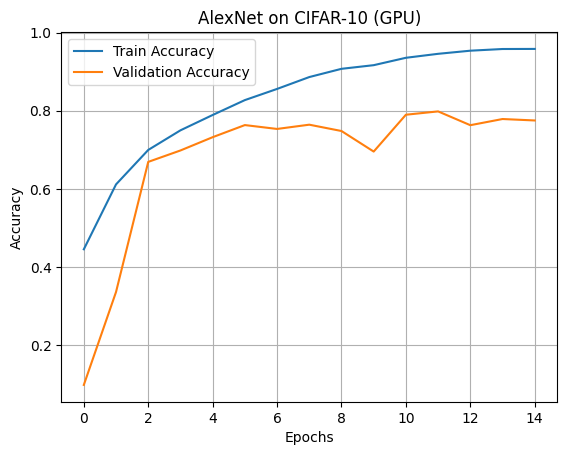

In [8]:
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('AlexNet on CIFAR-10 (GPU)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
